# General functions

In [53]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import math
import numpy as np
from numpy import sqrt, log, exp, pi, real, mean
import scipy.stats as st
from scipy.stats import norm, skew, kurtosis, probplot, poisson
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import least_squares

from fe_lib.black_scholes import BSM, BSM_greeks, BSM_vega, BSM_IV
from fe_lib.integration import GL_integration, trap_integration, default_gl_settings
from fe_lib.characteristic_functions import charFuncBSM, charFuncSV, charFuncJ, charFuncSVJ, charFuncKou
from fe_lib.pricing import price_and_iv, calibration_residuals, merton_series_price
from fe_lib.local_vol import bs_call_grid, risk_neutral_density, dupire_local_vol
from fe_lib.sabr import sigma_bs
from fe_lib.simulation import simulate_gbm_path, plain_mc_estimate, antithetic_estimate, control_variate_estimate
from fe_lib.lsm import simulate_heston_paths, terminal_diagnostics_table, european_put_from_paths, lsm_american_put, price_lsm_heston
from fe_lib.data import load_spx_returns, load_single_asset_options, load_option_grid
from fe_lib.plotting import save_and_show

# Set display options
np.set_printoptions(precision=4, suppress=True, floatmode='fixed')

def fmt(x, digits=4):
    return f"{x:.{digits}f}"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Lecture 1

### Analyzing time series of SPX returns

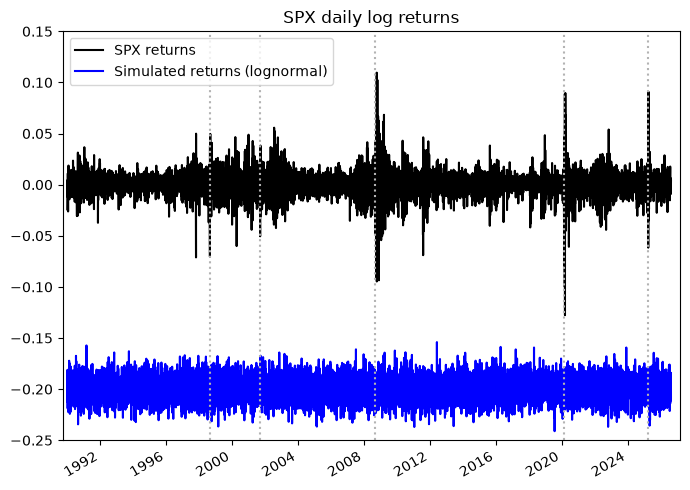

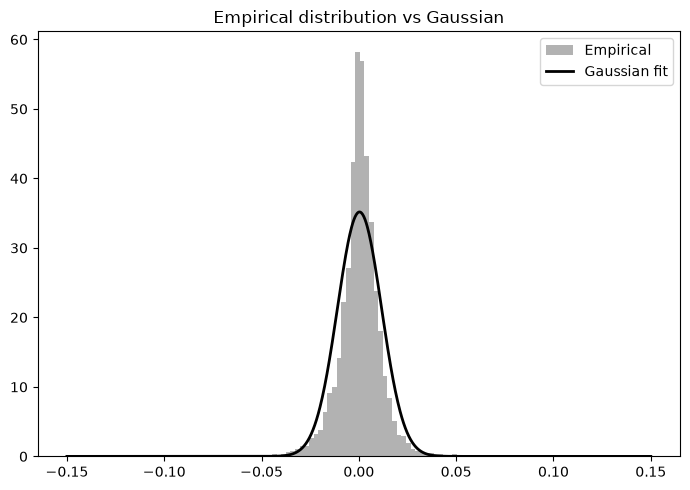

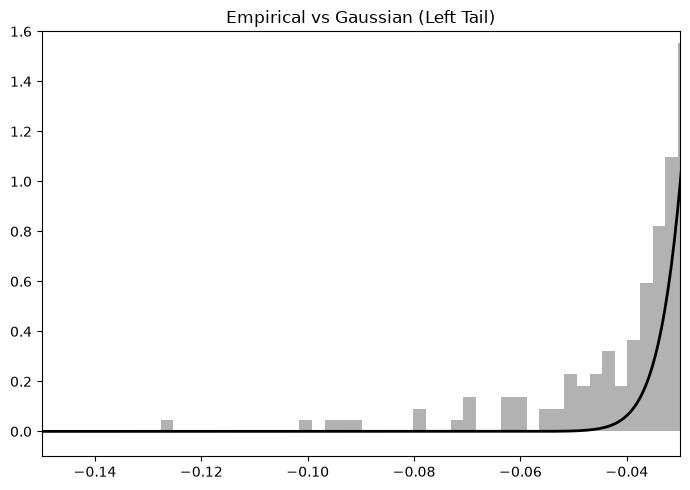

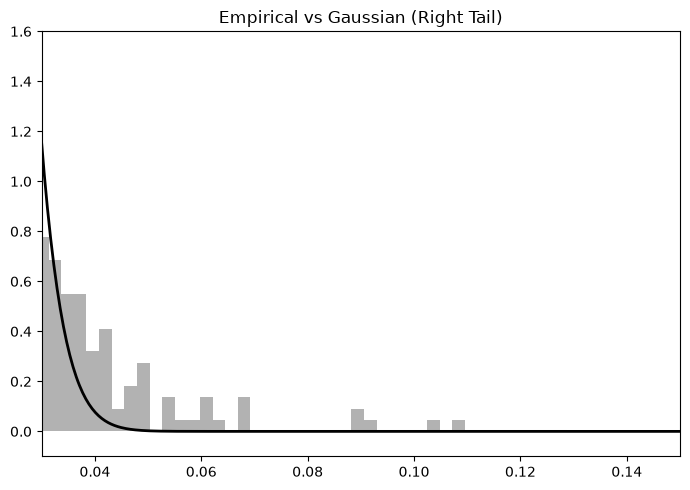

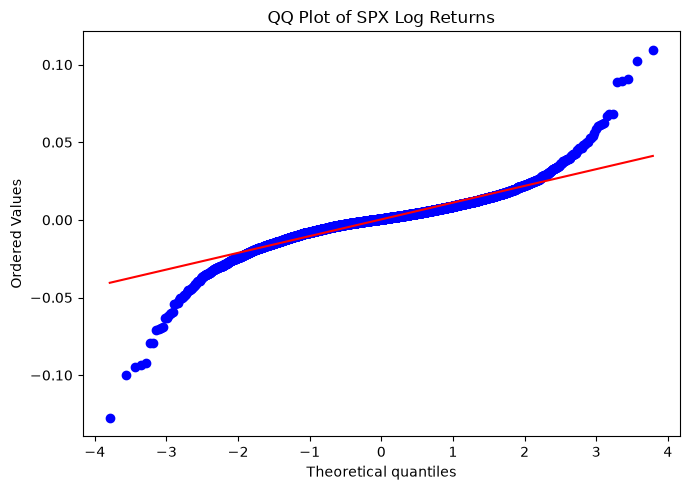

Mean: 0.0003317146038397809
Standard Deviation: 0.011341450922575377
Skewness: -0.36361447147026293
Kurtosis: 10.863698666300916


In [54]:
dates, SPX, SPXreturns = load_spx_returns()

# Simulate returns from normal distribution
simReturns = np.mean(SPXreturns) + np.std(SPXreturns) * np.random.randn(len(SPXreturns))

# Event dates
event_dates = {
    'LTCM crisis': pd.Timestamp(1998, 8, 29),
    '9/11 attack': pd.Timestamp(2001, 9, 18),
    'Lehman bankruptcy': pd.Timestamp(2008, 9, 15),
    'Covid-19 outbreak': pd.Timestamp(2020, 2, 15),
    'Tariff announcement': pd.Timestamp(2025, 4, 1)
}

# Create figure comparing actual SPX returns with simulated lognormal returns
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(dates, SPXreturns, '-k', label='SPX returns')
ax.plot(dates, simReturns - 0.20, '-b', label='Simulated returns (lognormal)')  # Shifted down for visibility
# Mark significant market events with vertical lines
for label, x in event_dates.items():
    ax.axvline(x, linestyle=':', color=[0.7, 0.7, 0.7])
ax.legend(loc='upper left')
ax.set_title('SPX daily log returns')
ax.set_ylim([-0.25, 0.15])
ax.set_xlim([dates.iloc[0] - pd.Timedelta(days=100), dates.iloc[-1] + pd.Timedelta(days=200)])
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()
save_and_show("Lecture1/fig_SPXdailyLogReturns.pdf")

# Create a histogram of SPX returns and overlay a Gaussian distribution for comparison
fig, ax = plt.subplots(figsize=(7,5))
n, bins, _ = ax.hist(SPXreturns, bins=100, density=True, alpha=0.6, color='gray', label='Empirical')
z = np.linspace(-0.15, 0.15, 1000)
y = norm.pdf(z, np.mean(SPXreturns), np.std(SPXreturns))
ax.plot(z, y, '-k', linewidth=2, label='Gaussian fit')
ax.set_title('Empirical distribution vs Gaussian')
ax.legend()
save_and_show("Lecture1/fig_empiricalDist.pdf")

# Zoom in on the left tail to examine extreme negative returns
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(SPXreturns, bins=100, density=True, alpha=0.6, color='gray')
ax.plot(z, y, '-k', linewidth=2)
ax.set_xlim([-0.15, -0.03])
ax.set_ylim([-0.1, 1.6])
ax.set_title('Empirical vs Gaussian (Left Tail)')
save_and_show("Lecture1/fig_empiricalDistLeft.pdf")

# Zoom in on the right tail to examine extreme positive returns
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(SPXreturns, bins=100, density=True, alpha=0.6, color='gray')
ax.plot(z, y, '-k', linewidth=2)
ax.set_xlim([0.03, 0.15])
ax.set_ylim([-0.1, 1.6])
ax.set_title('Empirical vs Gaussian (Right Tail)')
save_and_show("Lecture1/fig_empiricalDistRight.pdf")

# Create a Quantile-Quantile plot to assess normality of returns
fig, ax = plt.subplots(figsize=(7,5))
probplot(SPXreturns, dist="norm", plot=ax)
ax.set_title("QQ Plot of SPX Log Returns")
save_and_show("Lecture1/fig_qq.pdf")

# Calculate and print key statistical measures of the SPX log returns
print("Mean:", np.mean(SPXreturns))
print("Standard Deviation:", np.std(SPXreturns))
print("Skewness:", skew(SPXreturns))
print("Kurtosis:", kurtosis(SPXreturns))

### Illustration of BSM model

In [55]:
# Set initial parameters for the Black-Scholes-Merton model
S = 100        # Current stock price
K = 100        # Strike price
delta = 0.0    # Dividend yield
r = 0.05       # Risk-free interest rate
sigma = 0.20   # Volatility (20%)
T = 1 / 4      # Time to maturity in years (3 months)
optionType = "call"  # Option type (call option)

# Calculate the option price using the BSM model
price = BSM(S, K, delta, r, sigma, T, optionType)
print(f"BSM option price: {price:.4f}")
print("")

# Calculate the Greeks (sensitivity measures) for the option
Delta, gamma, vega, vanna, volga, theta = BSM_greeks(S, K, delta, r, sigma, T, optionType)
print(f"BSM vega: {vega:.4f}")  # Vega measures sensitivity to volatility changes
print("")

# Calculate the implied volatility (IV) using the BSM model
# Note: We're using sigma+0.05 as the initial guess, with price as the target
IV = BSM_IV(S, K, delta, r, sigma + 0.05, T, optionType, price, 0.00001, 1000, "Y")
print(f"Implied volatility: {IV:.4f}")

BSM option price: 4.6150

BSM vega: 19.6440

found on 2th iteration
difference is equal to  1.2610e-09
Implied volatility: 0.2000


# Assignment 1

### 1. Computing implied volatility smiles

Q1: Interest rate based on bid and ask prices: [0.0197 0.0205]

Option data:
        S  maturity  strike  type  price
0  286.68    0.2219     200   put   5.25
1     NaN       NaN     220   put   8.40
2     NaN       NaN     240   put  12.96
3     NaN       NaN     260   put  19.05
4     NaN       NaN     280   put  27.15
5     NaN       NaN     300  call  25.45
6     NaN       NaN     320  call  17.35
7     NaN       NaN     340  call  11.95
8     NaN       NaN     360  call   8.70

Q2: Plot of implied vol smile


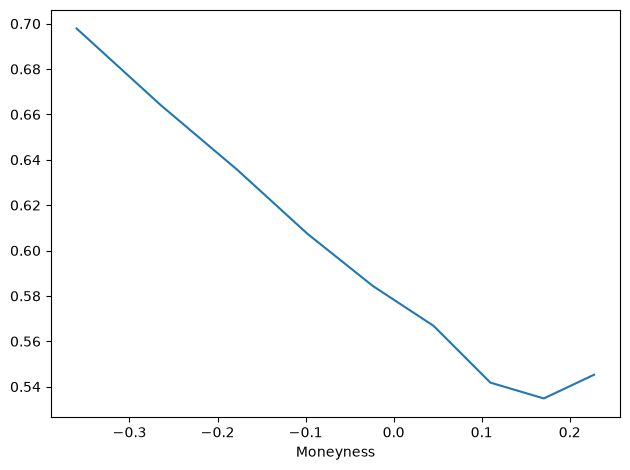

In [56]:
S = 286.68  # Current stock price
delta = 0  # Dividend yield (zero in this case)
tau = 0.2219  # Time to maturity in years

### Question 1: Inferring r from put-call parity
K = 280  # Strike price
C_bid = 34.90  # Bid price for call option
P_bid = 27.00  # Bid price for put option
r_bid = -log((S+P_bid-C_bid)/K)/tau  # Calculate interest rate using put-call parity with bid prices
C_ask = 35.25  # Ask price for call option
P_ask = 27.30  # Ask price for put option
r_ask = -log((S+P_ask-C_ask)/K)/tau  # Calculate interest rate using put-call parity with ask prices
res = np.array([r_bid, r_ask])  # Store both interest rates in an array
print("Q1: Interest rate based on bid and ask prices:",res)  # Print the results
print("")
r = 0.02  # Set interest rate for subsequent calculations

### Question 2: Computing implied vol smile
df = load_single_asset_options("Assignment_1.xlsx", sheet="TSLA")
print("Option data:")  # Print header
print(df)  # Display the loaded option data
print("")

N = len(df.strike)  # Get number of options in the dataset
IV = np.zeros(N)  # Create array to store implied volatilities, initialized with zeros
for n in range(N):  # Loop through each option
    K = df.strike[n]  # Get strike price for current option
    optionType = df.type[n]  # Get option type (call/put)
    price = df.price[n]  # Get market price of the option
    sigma0 = 0.50  # Initial guess for implied volatility
    # Calculate implied volatility using Black-Scholes-Merton model
    IV[n] = BSM_IV(S, K, delta, r, sigma0, tau, optionType, price, 0.00001, 1000, "N")

# Plotting the implied volatility smile
mness = log(df.strike / S)  # Calculate moneyness (log of strike/spot)
print("Q2: Plot of implied vol smile")
plt.plot(mness, IV)  # Create plot with moneyness on x-axis and implied volatility on y-axis
plt.xlabel('Moneyness')  # Label x-axis
save_and_show()

### 2. Pricing by characteristic function approach$-$the Black-Scholes model

Q2: Plot of integrands


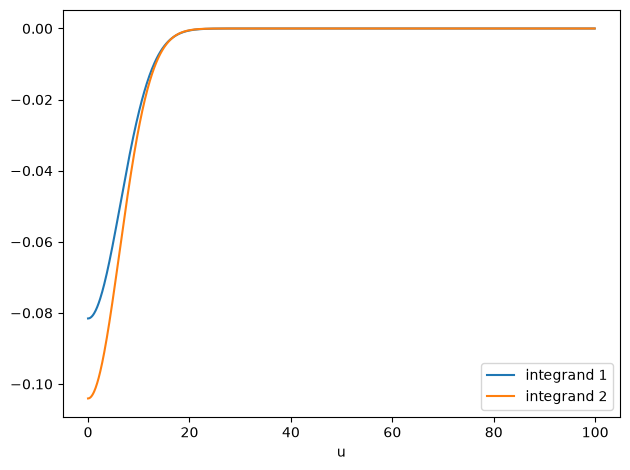

Q3: true price, Gauss-Legendre, Trapezoid: [25.6012 25.6019 25.6012]

Q4: Convergence to true price:
[[25.6012 23.8040 27.4405]
 [25.6012 25.6474 25.7277]
 [25.6012 25.7027 25.6056]
 [25.6012 25.5798 25.6012]
 [25.6012 25.6012 25.6012]
 [25.6012 25.6019 25.6012]]


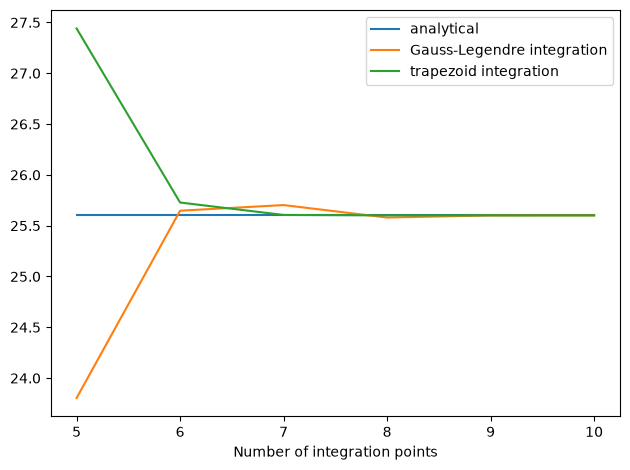

In [57]:
### Question 2: Plotting integrands
S = 1000
s = log(S)
r = 0.02
delta = 0.01
sigma = 0.30
tau = 1 / 4
K = 1100
bsm_params = {"S": S, "r": r, "delta": delta, "sigma": sigma}

uv = np.arange(0, 100, 0.1)  # points at which integrand is evaluated
lowerBound = 10 ** (-8) # note that we cannot evaluate integrand at 0
uv[0] = lowerBound

charFct2 = charFuncBSM(uv, tau, bsm_params)  # psi in pi2
integrand2 = real(exp(-1j * uv * log(K)) * charFct2 / (1j * uv))  # integrand in pi2
charFct1 = charFuncBSM(uv - 1j, tau, bsm_params) / (S * exp((r - delta) * tau))  # psi in pi1
integrand1 = real(exp(-1j * uv * log(K)) * charFct1 / (1j * uv))  # integrand in pi1

print("Q2: Plot of integrands")
plt.plot(uv, integrand1, uv, integrand2)
plt.gca().legend(('integrand 1', 'integrand 2'))
plt.xlabel('u')
save_and_show()

### Question 3: Comparison of integration schemes with analytical price
def callPrice(uv, wgtv):
    charFct1 = charFuncBSM(uv - 1j, tau, bsm_params) / (S * exp((r - delta) * tau))  # psi in pi1
    integrand1 = real(exp(-1j * uv * log(K)) * charFct1 / (1j * uv))  # integrand in pi1
    integral = sum(wgtv * integrand1)  # computing integral by numerical integration
    P1 = 1 / 2 + 1 / pi * integral
    charFct2 = charFuncBSM(uv, tau, bsm_params)  # psi in pi2
    integrand2 = real(exp(-1j * uv * log(K)) * charFct2 / (1j * uv))  # integrand in pi2
    integral = sum(wgtv * integrand2)  # computing integral by numerical integration
    P2 = 1 / 2 + 1 / pi * integral
    price = S * exp(-delta * tau) * P1 - K * exp(-r * tau) * P2  # call price
    return price

nPoints = 10  # number of integration points
upperBound = 50  # truncation of integral

# Price via the Gauss-Legendre integration scheme
uv_gl, wgtv_gl = GL_integration(upperBound, nPoints)
C_GL = callPrice(uv_gl, wgtv_gl)

# Price via trapezoid scheme
uv_tr, wgtv_tr = trap_integration(lowerBound, upperBound, nPoints)
C_Trap = callPrice(uv_tr, wgtv_tr)

# True price
C_true = BSM(S, K, delta, r, sigma, tau, "call")

res = np.array([C_true, C_GL, C_Trap])
print("Q3: true price, Gauss-Legendre, Trapezoid:",res)
print("")

### Question 4: Convergence to true price
nPointsv = np.linspace(5, 10, 6, dtype='int')
upperBound = 50
Cv = np.zeros((len(nPointsv), 3))  # preallocating
Cv[:, 0] = C_true
for i in range(len(nPointsv)):
    nPoints = nPointsv[i]
    uv_gl, wgtv_gl = GL_integration(upperBound, nPoints)
    Cv[i, 1] = callPrice(uv_gl, wgtv_gl)
    uv_tr, wgtv_tr = trap_integration(lowerBound, upperBound, nPoints)
    Cv[i, 2] = callPrice(uv_tr, wgtv_tr)

print("Q4: Convergence to true price:")
print(Cv)

plt.plot(nPointsv, Cv)
plt.gca().legend(('analytical', 'Gauss-Legendre integration', 'trapezoid integration'))
plt.xlabel('Number of integration points')
save_and_show()

# Lecture 2

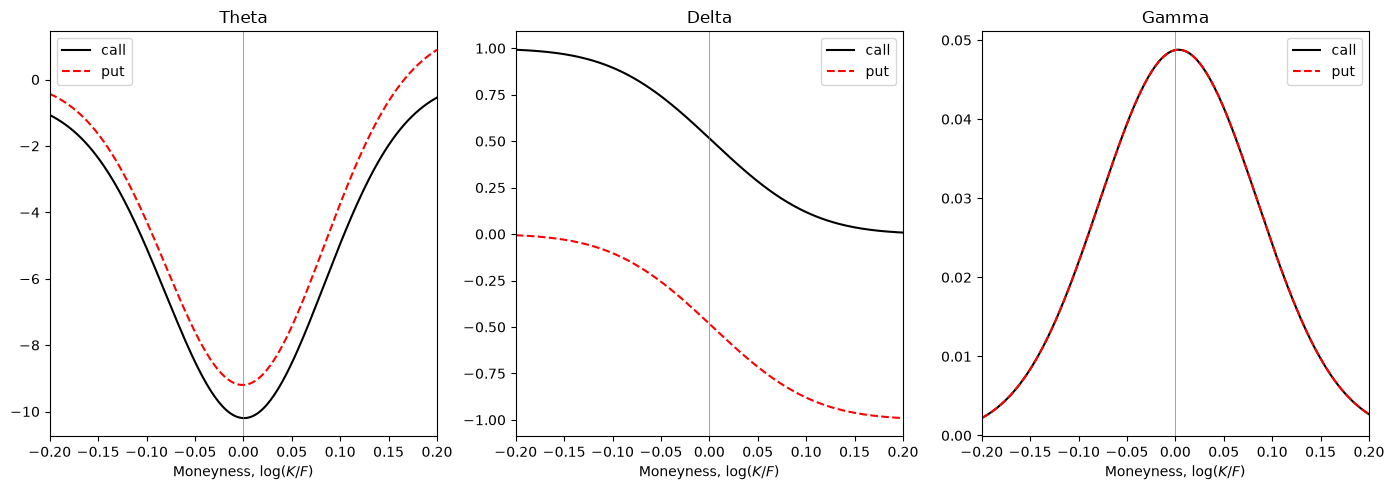

In [58]:
### Black-Scholes greeks across moneyness
S = 100
r = 0.02
delta = 0.01
sigma = 0.20
tau = 2 / 12  # 3 months to expiry

F = S * exp((r - delta) * tau)  # forward price
moneyness = np.linspace(-0.20, 0.20, 201)  # log(K/F)
Kv = F * exp(moneyness)  # strikes

greeks = {ot: BSM_greeks(S, Kv, delta, r, sigma, tau, ot) for ot in ("call", "put")}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (name, idx) in zip(axes, [("Theta", 5), ("Delta", 0), ("Gamma", 1)]):
    ax.plot(moneyness, greeks["call"][idx], '-k', label='call')
    ax.plot(moneyness, greeks["put"][idx], '--r', label='put')  # gamma coincides with the call
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(name)
    ax.set_xlabel('Moneyness, $\\log(K/F)$')
    ax.set_xlim(-0.20, 0.20)
    ax.legend()
save_and_show("Lecture2/BS_greeks.png")

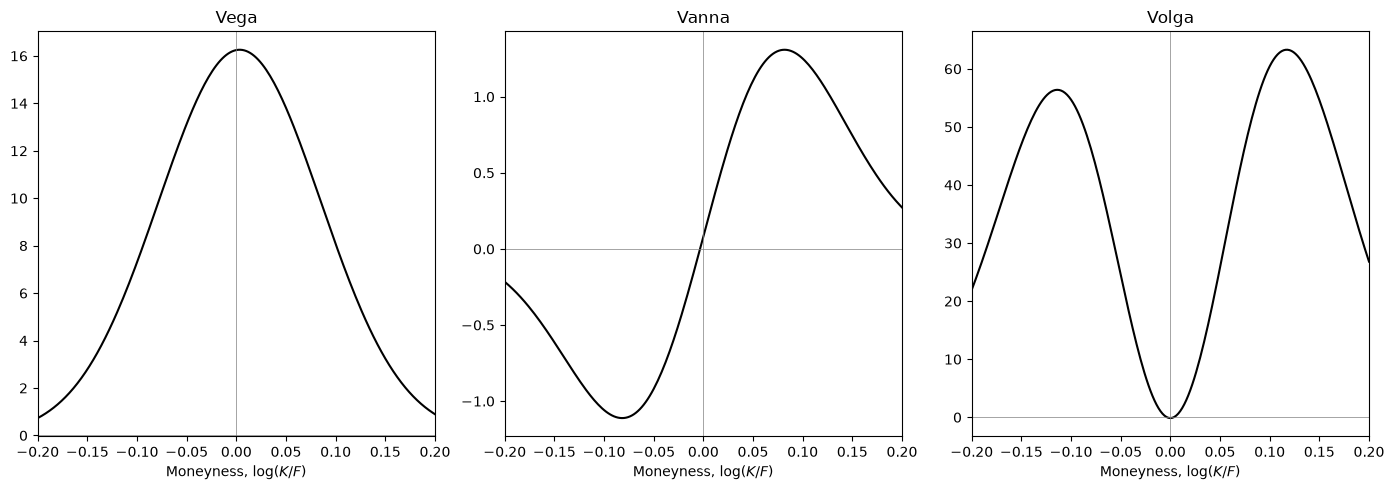

In [59]:
### Volatility greeks -- identical for calls and puts, so one line each
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (name, idx) in zip(axes, [("Vega", 2), ("Vanna", 3), ("Volga", 4)]):
    ax.plot(moneyness, greeks["call"][idx], '-k')
    ax.axvline(0, color='gray', lw=0.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_title(name)
    ax.set_xlabel('Moneyness, $\\log(K/F)$')
    ax.set_xlim(-0.20, 0.20)
save_and_show("Lecture2/BS_vol_greeks.png")

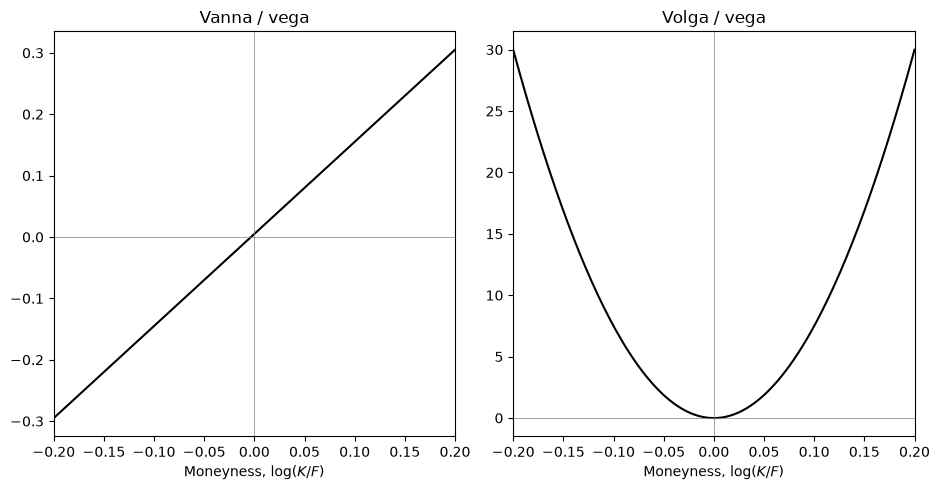

In [60]:
### Vanna and volga scaled by vega: vanna/vega = -d2/(sigma*S*sqrt(tau)), volga/vega = d1*d2/sigma
vega = greeks["call"][2]
ratios = [("Vanna / vega", greeks["call"][3] / vega), ("Volga / vega", greeks["call"][4] / vega)]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 5))
for ax, (name, y) in zip(axes, ratios):
    ax.plot(moneyness, y, '-k')
    ax.axvline(0, color='gray', lw=0.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_title(name)
    ax.set_xlabel('Moneyness, $\\log(K/F)$')
    ax.set_xlim(-0.20, 0.20)
save_and_show("Lecture2/BS_vega_scaled.png")

### Illustration of Heston model

In [61]:
settings = default_gl_settings(integration_points=100, upper_bound=200)
settings["model"] = "SV"
settings["plot_integrand"] = "N"

# initial stock price parameters
S = 100
r = 0.02
delta = 0.01

### Fixing strike/moneyness and studying the vol term structure

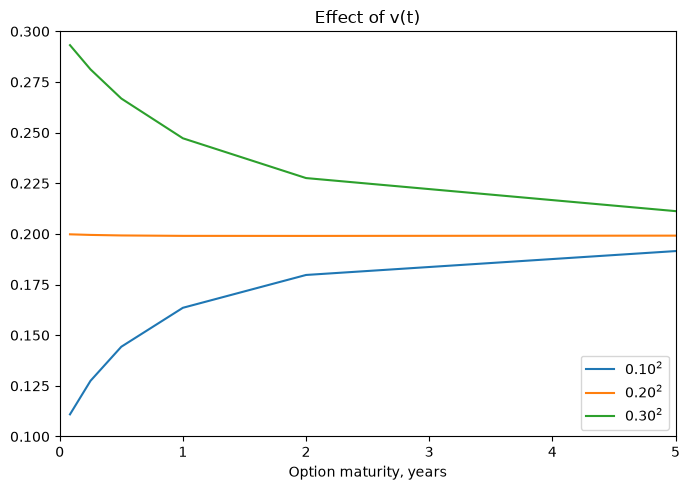

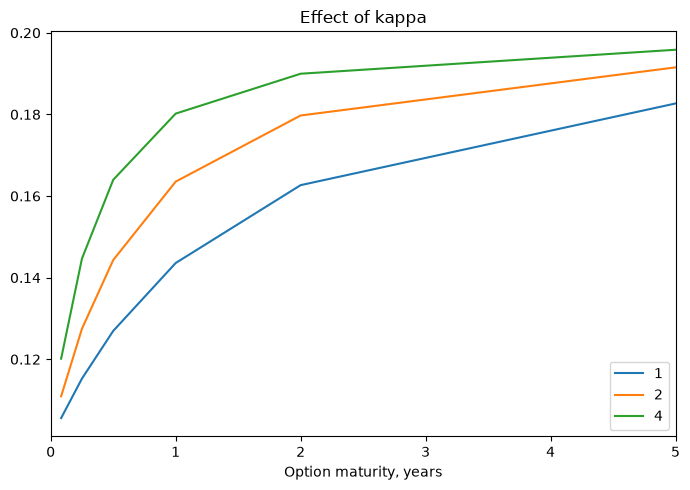

In [62]:
tauv = np.array([1 / 12, 3 / 12, 6 / 12, 1, 2, 5])  # maturities
forward_prices = exp((r - delta) * tauv) * S  # forward prices
strike = forward_prices  # ATM options
settings["tauv"] = tauv
settings["strike"] = strike.reshape((1, len(tauv)))

###--- Effect of v_t on volatility term structure
kappa = 2
theta = 0.20 ** 2
rho = -0.25
sigma = 0.1  # Easiest to see effect of v_t when sigma is low

parameters = {"S": S, "r": r, "delta": delta, "kappa": kappa, "theta": theta, "rho": rho, "sigma": sigma}

v0 = np.array([0.10 ** 2, 0.20 ** 2, 0.30 ** 2])
P = np.zeros((len(v0), len(tauv)))  # preallocating
IV = np.zeros((len(v0), len(tauv)))  # preallocating
for i in range(len(v0)):
    parameters["v"] = v0[i]
    P[i, :], IV[i, :] = price_and_iv(parameters, settings)

x = tauv.reshape((len(tauv), 1))
plt.subplots(figsize=(7,5))
plt.plot(x, IV.T)
plt.title('Effect of v(t)')
plt.legend(['$0.10^2$', '$0.20^2$', '$0.30^2$'], loc='lower right')
plt.xlim(0, 5)
plt.ylim(0.1, 0.3)
plt.xlabel('Option maturity, years')
save_and_show("Lecture2/Hes1.png")

###--- Effect of kappa on volatility term structure
theta = 0.20 ** 2
rho = -0.25
sigma = 0.1  # Easiest to see effect of v_t when sigma is low
v = 0.10 ** 2

parameters = {"S": S, "r": r, "delta": delta, "theta": theta, "rho": rho, "sigma": sigma, "v": v}

kappa = np.array([1, 2, 4])
P = np.zeros((len(kappa), len(tauv)))  # preallocating
IV = np.zeros((len(kappa), len(tauv)))  # preallocating
for i in range(len(kappa)):
    parameters["kappa"] = kappa[i]
    P[i, :], IV[i, :] = price_and_iv(parameters, settings)

x = tauv.reshape((len(tauv), 1))
plt.subplots(figsize=(7,5))
plt.plot(x, IV.T)
plt.title('Effect of kappa')
plt.legend(['1', '2', '4'], loc='lower right')
plt.xlim(0, 5)
plt.xlabel('Option maturity, years')
save_and_show("Lecture2/Hes2.png")

### Fixing maturity and studying vol smiles

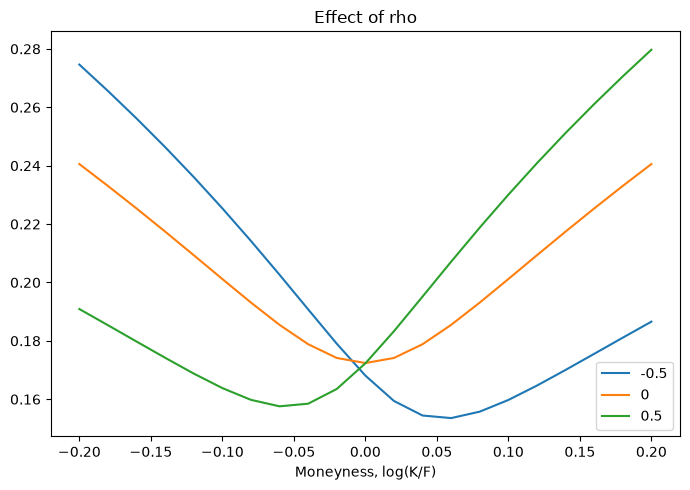

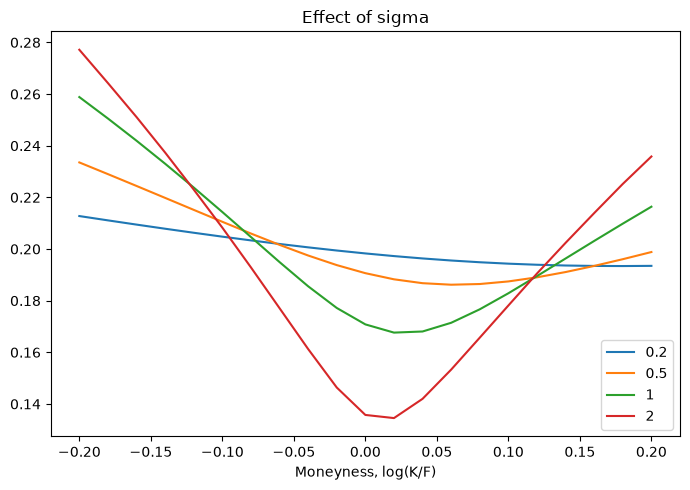

In [63]:
tauv = np.array([1 / 4])  # maturity
mness = np.arange(-0.20, 0.22, 0.02)  # moneyness
mness = mness.reshape((len(mness), 1))  # column vector
forward_price = exp((r - delta) * tauv) * S
strike = forward_price * exp(mness)
settings["tauv"] = tauv
settings["strike"] = strike

###--- Effect of rho on volatility smile
kappa = 2
theta = 0.20 ** 2
sigma = 1.00  # Easiest to see effect of rho when sigma is low
v = 0.20 ** 2

parameters = {"S": S, "r": r, "delta": delta, "kappa": kappa, "theta": theta, "sigma": sigma, "v": v}

rho = np.array([-0.5, 0, 0.5])
P = np.zeros((len(mness), len(rho)))  # preallocating
IV = np.zeros((len(mness), len(rho)))  # preallocating
for i in range(len(rho)):
    parameters["rho"] = rho[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P[:, i] = tmp1[:, 0]
    IV[:, i] = tmp2[:, 0]

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV)
plt.title('Effect of rho')
plt.legend(['-0.5', '0', '0.5'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture2/Hes3.png")

###--- Effect of sigma on volatility smile
kappa = 2
theta = 0.20 ** 2
rho = -0.25
v = 0.20 ** 2

parameters = {"S": S, "r": r, "delta": delta, "kappa": kappa, "theta": theta, "rho": rho, "v": v}

sigma = np.array([0.2, 0.5, 1, 2])
P = np.zeros((len(mness), len(sigma)))  # preallocating
IV = np.zeros((len(mness), len(sigma)))  # preallocating
for i in range(len(sigma)):
    parameters["sigma"] = sigma[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P[:, i] = tmp1[:, 0]
    IV[:, i] = tmp2[:, 0]

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV)
plt.title('Effect of sigma')
plt.legend(['0.2', '0.5', '1', '2'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture2/Hes4.png")

# Assignment 2

sigma_L: 0.1
sigma_H: 0.2645751311064591
Expected volatilty: 0.18228756555322956
Square-root of expected variance: 0.2

Q1: Option prices under stochastic volatility:
[184.4819 168.7056 152.8269 136.8991 120.9940 105.2192  89.7468  74.8445
  60.8844  48.2975  37.4673  28.6049  21.6763  16.4291  12.5003   9.5341
   7.2543   5.4759   4.0828   2.9984   2.1656]

Q2: Plot of implied vol smile


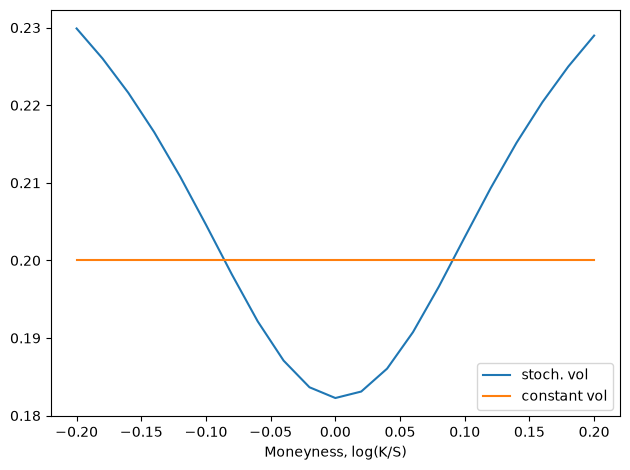

Q3: Plot of risk-neutral densities


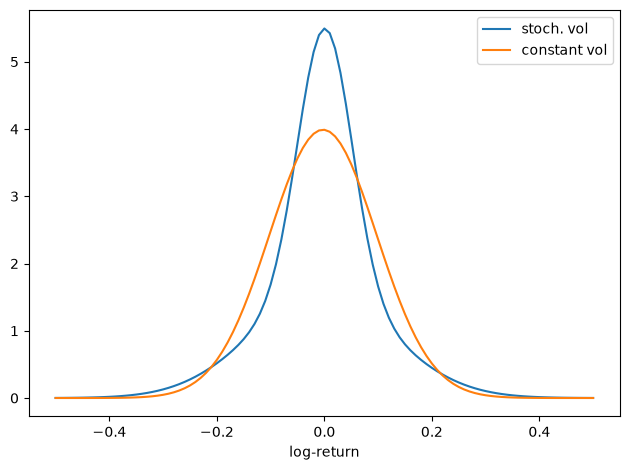

In [64]:
S = 1000
s = log(S)
r = 0.02
delta = 0.01
optionType = "call"
sigma = 0.20
sigma_L = sqrt(0.01)
sigma_H = sqrt(0.07)
E_sigma = 0.5*sigma_L+0.5*sigma_H
print("sigma_L:",sqrt(0.01))
print("sigma_H:",sqrt(0.07))
print("Expected volatilty:",E_sigma)
print("Square-root of expected variance:",sqrt(0.04))
print("")

tau = 1 / 4
mness = np.arange(-0.2, 0.21, 0.02)  # set op option moneyness
Kv = S*exp(mness)


### Question 1 and 2: Computing prices and implied vol smile
N = len(Kv)  # number of options
P = np.zeros(N)  # preallocating
IV = np.zeros(N)  # preallocating
for n in range(N):  # one strike at a time
    K = Kv[n]
    BS_L = BSM(S, K, delta, r, sigma_L, tau, optionType)
    BS_H = BSM(S, K, delta, r, sigma_H, tau, optionType)
    P[n] = 0.5*BS_L+0.5*BS_H
    sigma0 = 0.50  # initial guess
    IV[n] = BSM_IV(S, K, delta, r, sigma0, tau, optionType, P[n], 0.00001, 1000, "N")

print("Q1: Option prices under stochastic volatility:")
print(P)
print("")

# Plotting smile
IV_constVol = np.ones(N)*sigma
print("Q2: Plot of implied vol smile")
plt.plot(mness, IV)
plt.plot(mness, IV_constVol)
plt.legend(['stoch. vol','constant vol'], loc='lower right')
plt.xlabel('Moneyness, log(K/S)')
save_and_show()

### Question 3: Compute risk-neutral densities
ret = np.arange(-0.5, 0.51, 0.01)  # points at which integrand is evaluated
pdf_L = norm((r-delta-1/2*sigma_L**2)*tau,sigma_L*sqrt(tau)).pdf(ret)
pdf_H = norm((r-delta-1/2*sigma_H**2)*tau,sigma_H*sqrt(tau)).pdf(ret)
pdf_SV = 0.5*pdf_L+0.5*pdf_H
pdf_constVol = norm((r-delta-1/2*sigma**2)*tau,sigma*sqrt(tau)).pdf(ret)
print("Q3: Plot of risk-neutral densities")
plt.plot(ret,pdf_SV)
plt.plot(ret,pdf_constVol)
plt.legend(['stoch. vol','constant vol'], loc='upper right')
plt.xlabel('log-return')
save_and_show()

# Lecture 3

### Illustration of Jump-to-Ruin model

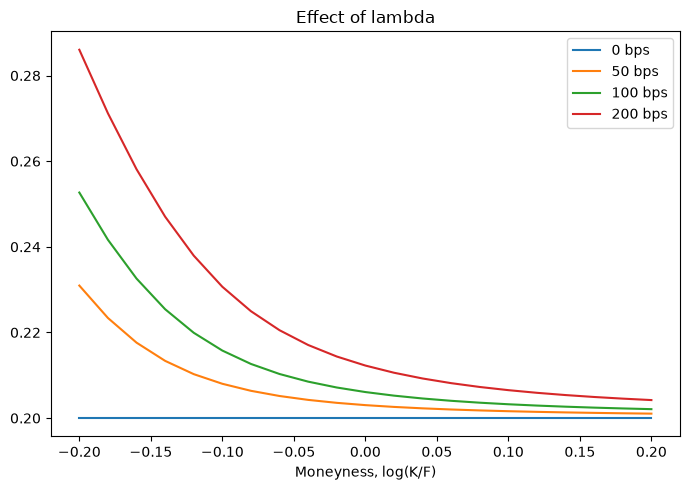

In [65]:
# initial stock price parameters
S = 100
r = 0.02
delta = 0.01
sigma = 0.20
lamb = np.array([0, 0.0050, 0.0100, 0.0200])

###### Fixing the moneyness dimension and stydying the vol smiles
tau = 1 / 4 # maturity
mness = np.arange(-0.20, 0.22, 0.02)  # moneyness
forward_price = exp((r - delta) * tau) * S  # forward price
strike = forward_price * exp(mness)

IV = np.zeros((len(mness), len(lamb)))  # preallocating
for i in range(len(lamb)):
    lam = lamb[i]
    for j in range(len(strike)):
        K = strike[j]
        P = BSM(S, K, delta, r + lam, sigma, tau, "call") #priced with r + lam
        sigma0 = 0.20  # initial guess
        IV[j, i] = BSM_IV(S, K, delta, r, sigma0, tau, "call", P, 0.00001, 1000, "N") #IV uses r

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV)
plt.title('Effect of lambda')
plt.legend(['0 bps', '50 bps', '100 bps', '200 bps'], loc='upper right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture3/JtR.png")

### Illustration of Merton model

Prices via characteristic function and Merton formula: [[2.4595]] 2.4594670788300084


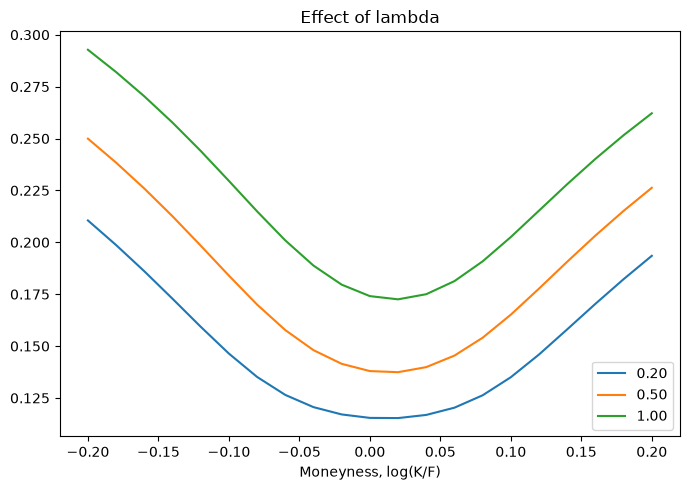

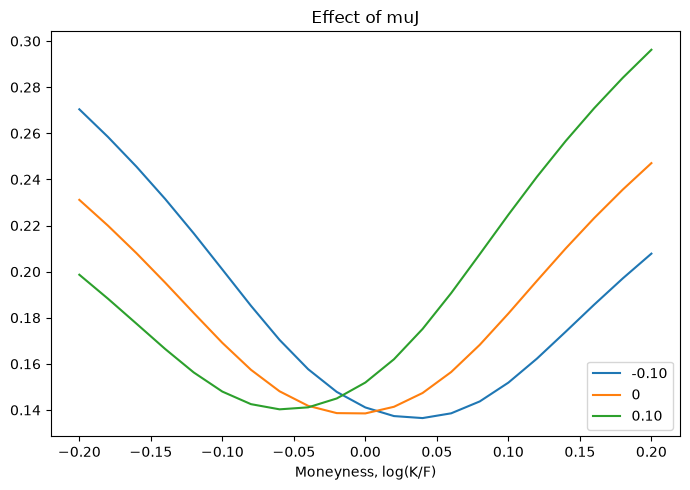

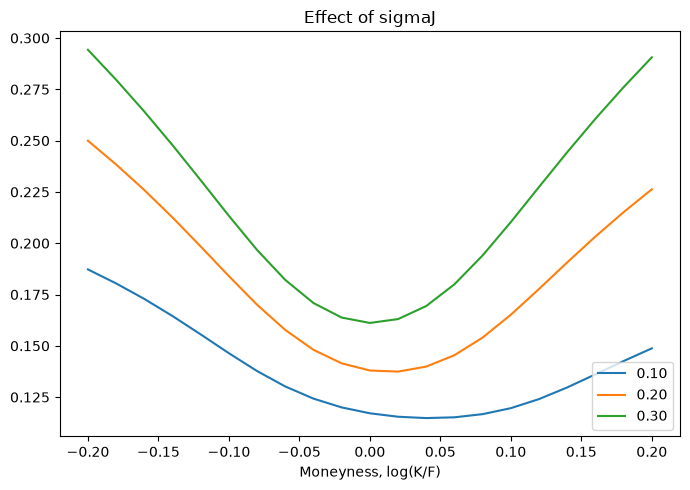

In [66]:
settings = default_gl_settings(integration_points=100, upper_bound=200)
settings["model"] = "J"
settings["plot_integrand"] = "N"

# initial stock price parameters
S = 100
r = 0.02
delta = 0.01

###### Testing formulas
tauv = np.array([1 / 4])  # maturity
strike = np.array([S])  # strike
settings["tauv"] = tauv
settings["strike"] = strike.reshape((1, 1))
parameters = {"S": S, "r": r, "delta": delta, "sigma": 0.10, "lamb": 0.50, "muJ": -0.05, "sigmaJ": 0.10}
transformPrice, transformIV = price_and_iv(parameters, settings)
merton_settings = {"strike": float(strike[0]), "tauv": float(tauv[0]), "truncation": 10}
mertonPrice = merton_series_price(parameters, merton_settings)

print("Prices via characteristic function and Merton formula:",transformPrice, mertonPrice)

###### Fixing the moneyness dimension and stydying the vol smiles
tauv = np.array([1 / 4])  # maturity
mness = np.arange(-0.20, 0.22, 0.02)  # moneyness
mness = mness.reshape((len(mness), 1))  # column vector
forward_price = exp((r - delta) * tauv) * S
strike = forward_price * exp(mness)
settings["tauv"] = tauv
settings["strike"] = strike

###--- Effect of lambda on volatility smile
sigma = 0.10
muJ = -0.05
sigmaJ = 0.20

parameters = {"S": S, "r": r, "delta": delta, "sigma": sigma, "muJ": muJ, "sigmaJ": sigmaJ}

lamb = np.array([0.20, 0.50, 1])
P = np.zeros((len(mness), len(lamb)))  # preallocating
IV = np.zeros((len(mness), len(lamb)))  # preallocating
for i in range(len(lamb)):
    parameters["lamb"] = lamb[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P[:, i] = tmp1[:, 0]
    IV[:, i] = tmp2[:, 0]

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV)
plt.title('Effect of lambda')
plt.legend(['0.20', '0.50', '1.00'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture3/Mer1.png")

###--- Effect of muJ on volatility smile
sigma = 0.10
lamb = 0.50
sigmaJ = 0.20

parameters = {"S": S, "r": r, "delta": delta, "sigma": sigma, "lamb": lamb, "sigmaJ": sigmaJ}

muJ = np.array([-0.10, 0, 0.10])
P = np.zeros((len(mness), len(muJ)))  # preallocating
IV = np.zeros((len(mness), len(muJ)))  # preallocating
for i in range(len(muJ)):
    parameters["muJ"] = muJ[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P[:, i] = tmp1[:, 0]
    IV[:, i] = tmp2[:, 0]

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV)
plt.title('Effect of muJ')
plt.legend(['-0.10', '0', '0.10'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture3/Mer2.png")

###--- Effect of sigmaJ on volatility smile
sigma = 0.10
lamb = 0.50
muJ = -0.05

parameters = {"S": S, "r": r, "delta": delta, "sigma": sigma, "lamb": lamb, "muJ": muJ}

sigmaJ = np.array([0.10, 0.20, 0.30])
P = np.zeros((len(mness), len(sigmaJ)))  # preallocating
IV = np.zeros((len(mness), len(sigmaJ)))  # preallocating
for i in range(len(sigmaJ)):
    parameters["sigmaJ"] = sigmaJ[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P[:, i] = tmp1[:, 0]
    IV[:, i] = tmp2[:, 0]

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV)
plt.title('Effect of sigmaJ')
plt.legend(['0.10', '0.20', '0.30'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture3/Mer3.png")

### Comparison of double-exponential and normal densities

Equivalent Merton jump mean_ -0.02666666666666667
Equivalent Merton jump st. dev.: 0.09043106644167023


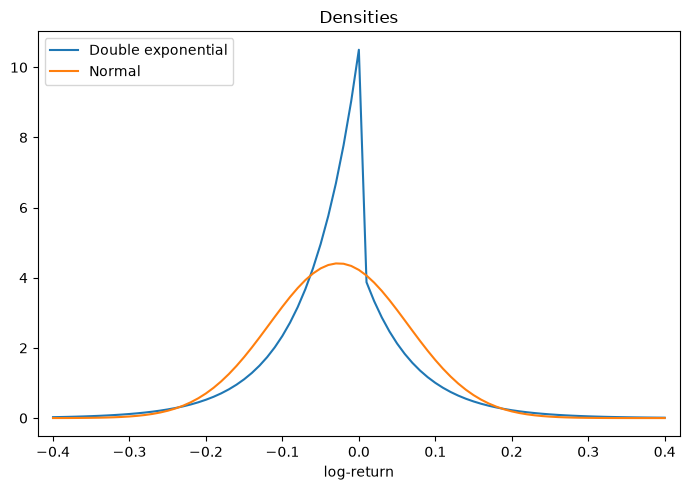

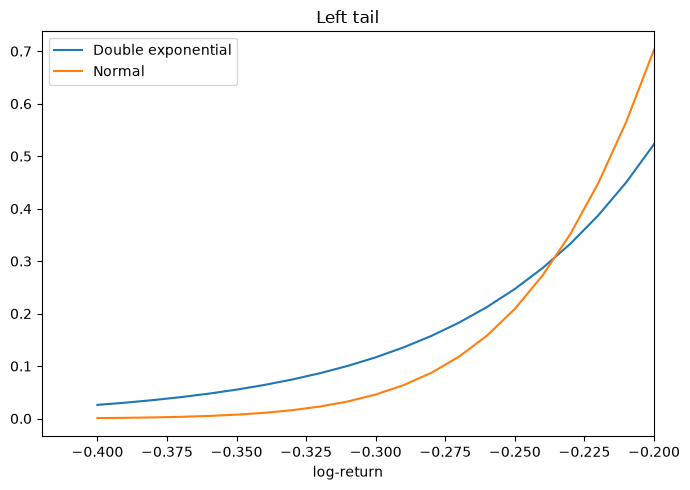

In [67]:
# Double-exponential parameters
p = 0.3
eta = 15
# equivalent normal parameters
muJ = (2*p-1) / eta
sigmaJ = sqrt( (4*p*(1-p)+1) / (eta**2) )
print("Equivalent Merton jump mean_",muJ)
print("Equivalent Merton jump st. dev.:",sigmaJ)
y = np.arange(-0.40, 0.41, 0.01)  # log-return range
y = y.reshape((len(y), 1))  # column vector
# Double-exponential density
f_Kou = np.zeros((len(y), 1))
f_Kou[0:41] = (1-p)*eta*exp(eta*y[0:41])
f_Kou[41:len(y)] = p*eta*exp(-eta*y[41:len(y)])
# Normal density
f_Mer = norm.pdf(y, loc=muJ, scale=sigmaJ)

plt.subplots(figsize=(7,5))
plt.plot(y, f_Kou, y, f_Mer)
plt.title('Densities')
plt.legend(['Double exponential', 'Normal'], loc='upper left')
plt.xlim(-0.42, 0.42)
plt.xlabel('log-return')
save_and_show("Lecture3/Kou_dist.png")

plt.subplots(figsize=(7,5))
plt.plot(y[0:21], f_Kou[0:21], y[0:21], f_Mer[0:21])
plt.title('Left tail')
plt.legend(['Double exponential', 'Normal'], loc='upper left')
plt.xlim(-0.42, -0.20)
plt.xlabel('log-return')
save_and_show("Lecture3/Kou_dist2.png")

### Illustration of Kou model

Equivalent Merton jump mean_ [-0.0533  0.0533]
Equivalent Merton jump st. dev.: [0.0777 0.0777]


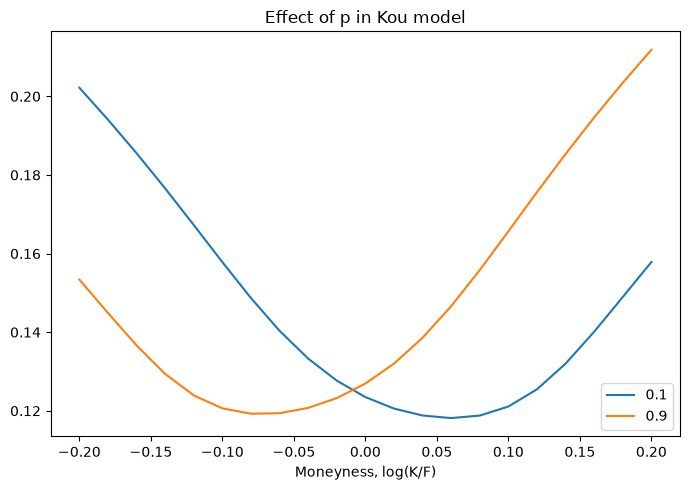

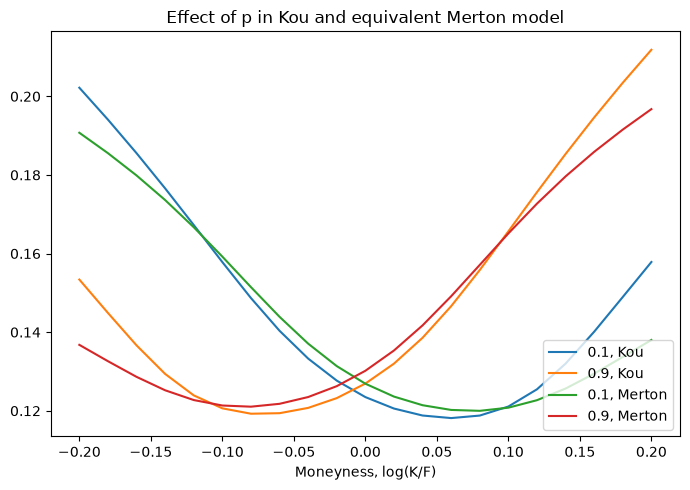

Equivalent Merton jump mean_ [0.0000 0.0000]
Equivalent Merton jump st. dev.: [0.0707 0.1414]


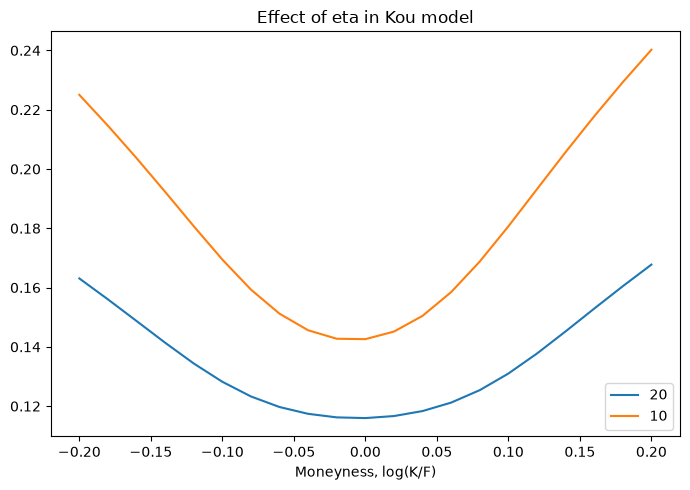

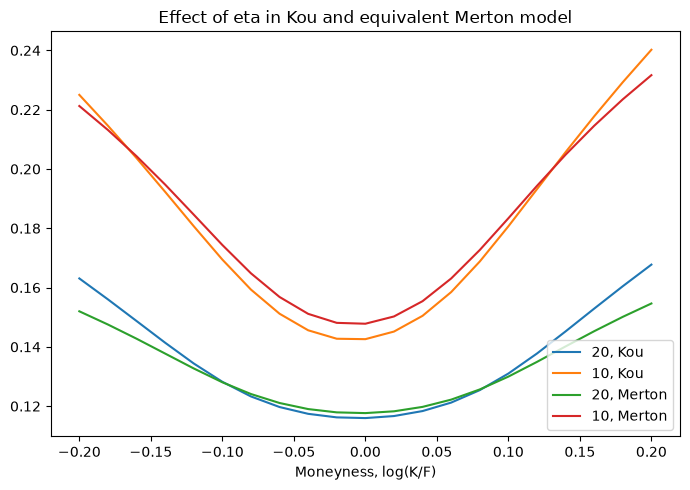

In [68]:
settings = default_gl_settings(integration_points=100, upper_bound=200)
settings["plot_integrand"] = "N"

# initial stock price parameters
S = 100
r = 0.02
delta = 0.01

###### Fixing the moneyness dimension and stydying the vol smiles
tauv = np.array([1 / 4])  # maturity
mness = np.arange(-0.20, 0.22, 0.02)  # moneyness
mness = mness.reshape((len(mness), 1))  # column vector
forward_price = exp((r - delta) * tauv) * S
strike = forward_price * exp(mness)
settings["tauv"] = tauv
settings["strike"] = strike

sigma = 0.10
lamb = 1
parameters = {"S": S, "r": r, "delta": delta, "sigma": sigma, "lamb": lamb}

###--- Effect of p on skewness of volatility smile
eta = 15
parameters["eta"] = eta
p = np.array([0.1, 0.9])
muJ = (2*p-1) / eta
sigmaJ = sqrt( (4*p*(1-p)+1) / (eta**2) )
print("Equivalent Merton jump mean_",muJ)
print("Equivalent Merton jump st. dev.:",sigmaJ)
P_Kou = np.zeros((len(mness), len(p)))  # preallocating
IV_Kou = np.zeros((len(mness), len(p)))  # preallocating
P_Merton = np.zeros((len(mness), len(p)))  # preallocating
IV_Merton = np.zeros((len(mness), len(p)))  # preallocating
for i in range(len(p)):
    #Kou model
    settings["model"] = "Kou"
    parameters["p"] = p[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P_Kou[:, i] = tmp1[:, 0]
    IV_Kou[:, i] = tmp2[:, 0]
    #Merton model, where distribution of jumps in log-price has same mean and variance
    settings["model"] = "J"
    parameters["muJ"] = muJ[i]
    parameters["sigmaJ"] = sigmaJ[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P_Merton[:, i] = tmp1[:, 0]
    IV_Merton[:, i] = tmp2[:, 0]

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV_Kou)
plt.title('Effect of p in Kou model')
plt.legend(['0.1', '0.9'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture3/Kou1.png")

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV_Kou,x, IV_Merton)
plt.title('Effect of p in Kou and equivalent Merton model')
plt.legend(['0.1, Kou', '0.9, Kou', '0.1, Merton', '0.9, Merton'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture3/KouMer1.png")

###--- Effect of eta on curvature of volatility smile
p = 0.5
parameters["p"] = p
eta = np.array([20, 10])
muJ = (2*p-1) / eta
sigmaJ = sqrt( (4*p*(1-p)+1) / (eta**2) )
print("Equivalent Merton jump mean_",muJ)
print("Equivalent Merton jump st. dev.:",sigmaJ)
P_Kou = np.zeros((len(mness), len(eta)))  # preallocating
IV_Kou = np.zeros((len(mness), len(eta)))  # preallocating
P_Merton = np.zeros((len(mness), len(eta)))  # preallocating
IV_Merton = np.zeros((len(mness), len(eta)))  # preallocating
for i in range(len(eta)):
    #Kou model
    settings["model"] = "Kou"
    parameters["eta"] = eta[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P_Kou[:, i] = tmp1[:, 0]
    IV_Kou[:, i] = tmp2[:, 0]
    #Merton model, where distribution of jumps in log-price has same mean and variance
    settings["model"] = "J"
    parameters["muJ"] = muJ[i]
    parameters["sigmaJ"] = sigmaJ[i]
    tmp1, tmp2 = price_and_iv(parameters, settings)
    P_Merton[:, i] = tmp1[:, 0]
    IV_Merton[:, i] = tmp2[:, 0]

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV_Kou)
plt.title('Effect of eta in Kou model')
plt.legend(['20', '10'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture3/Kou2.png")

x = mness
plt.subplots(figsize=(7,5))
plt.plot(x, IV_Kou,x, IV_Merton)
plt.title('Effect of eta in Kou and equivalent Merton model')
plt.legend(['20, Kou', '10, Kou', '20, Merton', '10, Merton'], loc='lower right')
plt.xlim(-0.22, 0.22)
plt.xlabel('Moneyness, log(K/F)')
save_and_show("Lecture3/KouMer2.png")

# Assignment 3

### 1. The Merton model

Q1: Expected number of jumps : 0.5
Q1: Likelihood of 0, 1, 2, >2 jumps : [0.6065 0.3033 0.0758 0.0144]

Q3: Implied volatility smiles


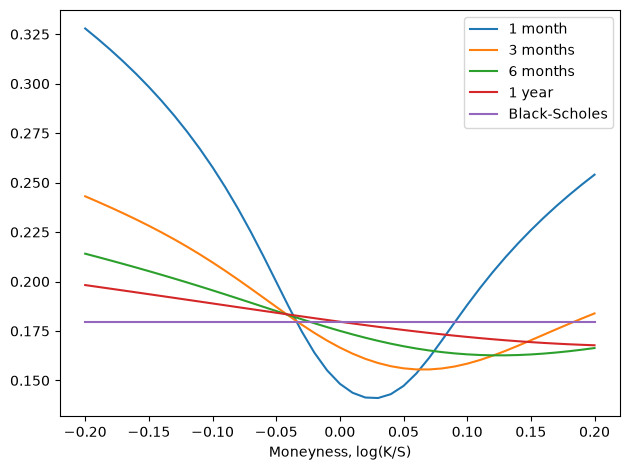

Q4: Risk-neutral densities


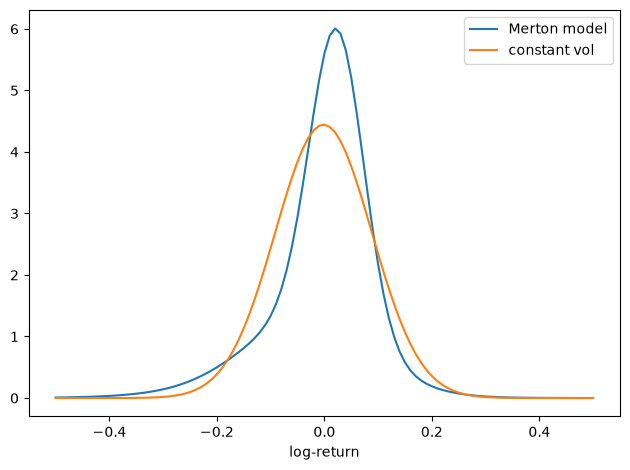

In [69]:
S = 1000
s = log(S)
r = 0.02
delta = 0.01
sigma = 0.10
lamb = 2
muJ = -0.05
sigmaJ = 0.10
sigma_const = sqrt(sigma**2+lamb*((exp(2*muJ+2*sigmaJ**2)-2*exp(muJ+1/2*sigmaJ**2)+1)))
optionType = "call"
parameters = {"S": S, "r": r, "delta": delta, "sigma": sigma, "lamb": lamb, "muJ": muJ, "sigmaJ": sigmaJ}


### Question 1: Jump probabilities
tau = 3/12
print("Q1: Expected number of jumps :",lamb*tau)

res = np.zeros(4)
res[0] = poisson.pmf(k=0, mu=lamb*tau)
res[1] = poisson.pmf(k=1, mu=lamb*tau)
res[2] = poisson.pmf(k=2, mu=lamb*tau)
res[3] = 1-poisson.cdf(k=2, mu=lamb*tau)
print("Q1: Likelihood of 0, 1, 2, >2 jumps :",res)
print("")


### Question 2 and 3: Computing prices and implied vol smile
tauv = np.array([1 / 12, 3 / 12, 1/2, 1])  # maturities
mness = np.arange(-0.2, 0.21, 0.01)
Kv = S*exp(mness)
N = len(tauv)  # number of maturities
M = len(Kv)  # number of strikes
P = np.zeros([M,N])  # preallocating
IV = np.zeros([M,N])  # preallocating
for n in range(N):  # one strike at a time
    tau = tauv[n]
    for m in range(M):  # one maturity at a time
        K = Kv[m]
        merton_settings = {"strike": K, "tauv": tau, "truncation": 10}
        P[m,n] = merton_series_price(parameters, merton_settings)
        sigma0 = 0.50  # initial guess
        IV[m,n] = BSM_IV(S, K, delta, r, sigma0, tau, optionType, P[m,n], 0.00001, 1000, "N")

x = mness.reshape((len(mness), 1))
plt.plot(x, IV)
plt.plot(x, sigma_const*np.ones([M,1]))
plt.legend(['1 month','3 months','6 months','1 year','Black-Scholes'], loc='upper right')
plt.xlabel('Moneyness, log(K/S)')
print("Q3: Implied volatility smiles")
save_and_show()


### Question 4: Compute risk-neutral densities
tau = 1/4
ret = np.arange(-0.5, 0.51, 0.01)  # points at which integrand is evaluated
truncation = 10
mu_bar = exp(muJ + 1 / 2 * sigmaJ ** 2) - 1
pdf_Merton = 0
for k in range(truncation):
    sigma_k = sqrt(sigma ** 2 + k / tau * sigmaJ ** 2)
    r_k = r - mu_bar * lamb + k / tau * (muJ + 1 / 2 * sigmaJ ** 2)
    prob = exp(-lamb * tau) * (lamb * tau) ** k / math.factorial(k)
    pdf_Merton = pdf_Merton+prob*norm((r_k-delta-1/2*sigma_k**2)*tau,sigma_k*sqrt(tau)).pdf(ret)

pdf_constVol = norm((r-delta-1/2*sigma_const**2)*tau,sigma_const*sqrt(tau)).pdf(ret)
plt.plot(ret,pdf_Merton)
plt.plot(ret,pdf_constVol)
plt.legend(['Merton model','constant vol'], loc='upper right')
plt.xlabel('log-return')
print("Q4: Risk-neutral densities")
save_and_show()

# Lecture 4

### Risk neutral densities

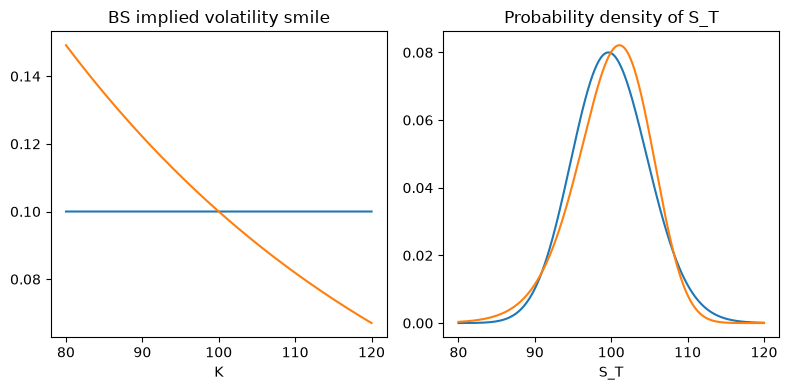

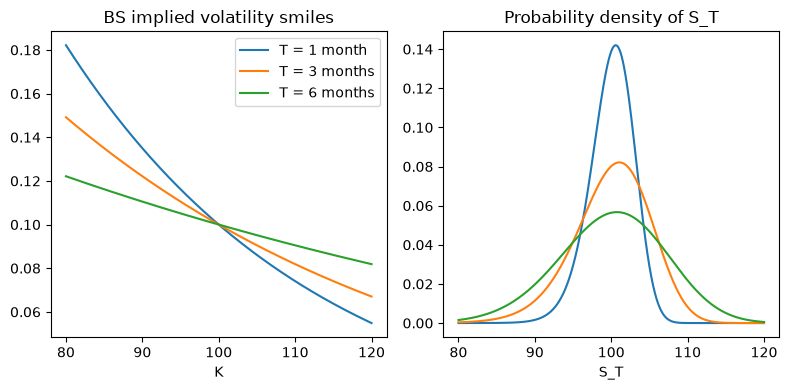

In [70]:
dT = 0.01
dK = 0.01
S = 100
Kv = np.arange(80, 120 + dK, dK)
r = 0
delta = 0
T = 0.25

### Flat & Skewed Implied Vol
sigv = np.zeros((len(Kv), 2))
qT = np.zeros((len(Kv) - 2, 2))

# Flat volatility
sigmav = 0.1 * np.ones_like(Kv)
sigv[:, 0] = sigmav
CT = bs_call_grid(S, Kv, delta, r, sigmav, T)
qT[:, 0] = risk_neutral_density(CT, dK)

# Skewed volatility
sigmav = 0.1 * np.exp(-2 * (Kv / S - 1))
sigv[:, 1] = sigmav
CT = bs_call_grid(S, Kv, delta, r, sigmav, T)
qT[:, 1] = risk_neutral_density(CT, dK)

# Plot: Implied volatility smile and density
plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.plot(Kv[1:-1], sigv[1:-1])
plt.title('BS implied volatility smile')
plt.xlabel('K')

plt.subplot(1, 2, 2)
plt.plot(Kv[1:-1], qT)
plt.title('Probability density of S_T')
plt.xlabel('S_T')
save_and_show("Lecture4/fig_density.pdf")

### Volatility smiles for different maturities
sigv = np.zeros((len(Kv), 3))
qT = np.zeros((len(Kv) - 2, 3))
av = np.array([3, 2, 1])
Tv = np.array([1, 3, 6]) / 12  # in years

for j in range(len(Tv)):
    T = Tv[j]
    a = av[j]
    sigmav = 0.1 * np.exp(-a * (Kv / S - 1))
    sigv[:, j] = sigmav
    CT = bs_call_grid(S, Kv, r, r, sigmav, T)  # delta passed as r too (r=0 here, so it's a no-op)
    qT[:, j] = risk_neutral_density(CT, dK)

# Plot: Vol smiles and densities
plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.plot(Kv[1:-1], sigv[1:-1])
plt.title('BS implied volatility smiles')
plt.xlabel('K')
plt.legend(['T = 1 month', 'T = 3 months', 'T = 6 months'], loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(Kv[1:-1], qT)
plt.title('Probability density of S_T')
plt.xlabel('S_T')
save_and_show("Lecture4/fig_density2.pdf")

### Local Volatility Estimation (Dupire)

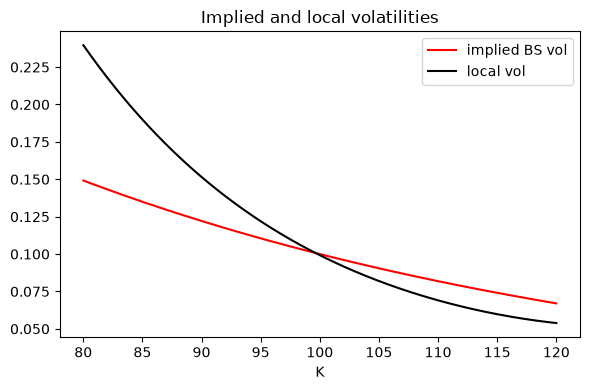

In [71]:
sigmav = 0.1 * np.exp(-2 * (Kv / S - 1))
T = 0.25
LV = dupire_local_vol(S, Kv, r, delta, sigmav, T, dT, dK)

# Plot: Local vs implied volatility
plt.figure(figsize=(6,4))
plt.plot(Kv[1:-1], sigmav[1:-1], 'r-', label='implied BS vol')
plt.plot(Kv[1:-1], np.sqrt(LV), 'k-', label='local vol')
plt.title('Implied and local volatilities')
plt.xlabel('K')
plt.legend()
save_and_show("Lecture4/fig_LV.pdf")

### Illustration of SABR model

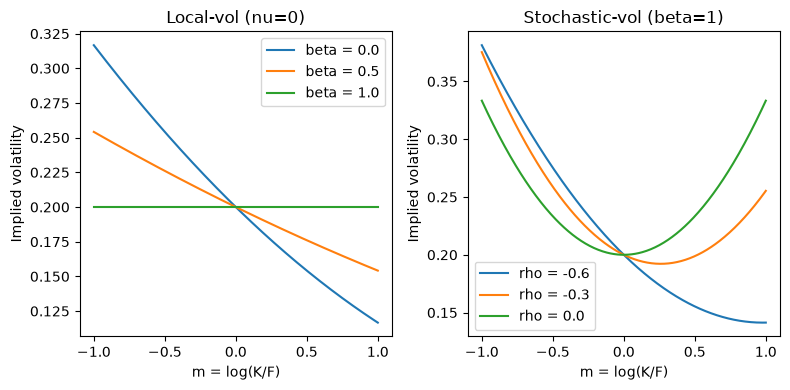

In [78]:
# ---- Simplified SABR formula ----
# m = log(K/F_t),  lambda = nu / (alpha_t * F_t^(beta-1))

# Grid in log-moneyness
m = np.linspace(-1.0, 1.0, 401)
F_t = 1.0  # set F_t=1 so ATM vol equals alpha_t

fig, ax = plt.subplots(1, 2, figsize=(8,4))

# ---- Left plot: nu=0, alpha=0.20; beta in {0, 0.5, 1} ----
nu_left = 0.0
alpha_left = 0.20  # ATM vol = 20%
for beta in [0.0, 0.5, 1.0]:
    vols = sigma_bs(m, alpha_left, beta, rho=0.0, nu=nu_left, F_t=F_t)
    ax[0].plot(m, vols, label=f"beta = {beta}")
ax[0].set_title("Local-vol (nu=0)")
ax[0].set_xlabel("m = log(K/F)")
ax[0].set_ylabel("Implied volatility")
ax[0].legend()

# ---- Right plot: beta=1; rho in {-0.6, -0.3, 0}; adjust alpha_t so ATM=20% ----
beta_right = 1.0
alpha_atm = 0.20  # with beta=1 and F=1, ATM vol is exactly alpha_t
nu_right = 0.40   # choose a reasonable vol-of-vol to show curvature
for rho in [-0.6, -0.3, 0.0]:
    vols = sigma_bs(m, alpha_atm, beta_right, rho=rho, nu=nu_right, F_t=F_t)
    ax[1].plot(m, vols, label=f"rho = {rho}")
ax[1].set_title("Stochastic-vol (beta=1)")
ax[1].set_xlabel("m = log(K/F)")
ax[1].set_ylabel("Implied volatility")
ax[1].legend()

save_and_show("Lecture4/SABR.pdf")

# Assignment 4

Q1: Plot the integrand


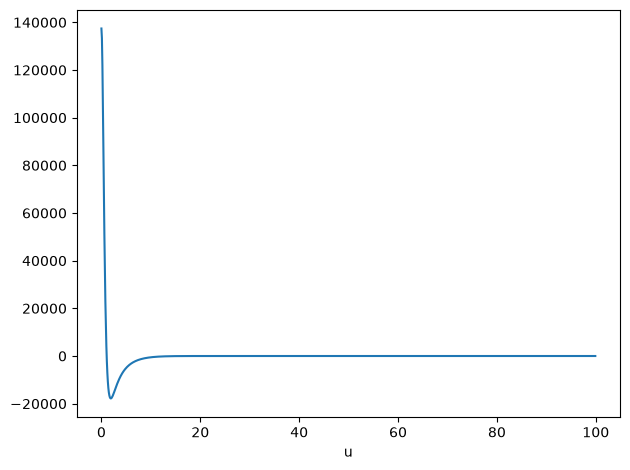

Q2: Option prices [25.6012 25.6207 48.9748]

Q3: Convergence to true price: [[ 25.6012  43.7055 304.2443]
 [ 25.6012  24.5525 143.5182]
 [ 25.6012  25.5409  77.6894]
 [ 25.6012  25.6207  48.9748]
 [ 25.6012  25.5993  36.1711]
 [ 25.6012  25.6012  30.4005]
 [ 25.6012  25.6012  27.7849]
 [ 25.6012  25.6012  26.5958]
 [ 25.6012  25.6012  26.0544]]



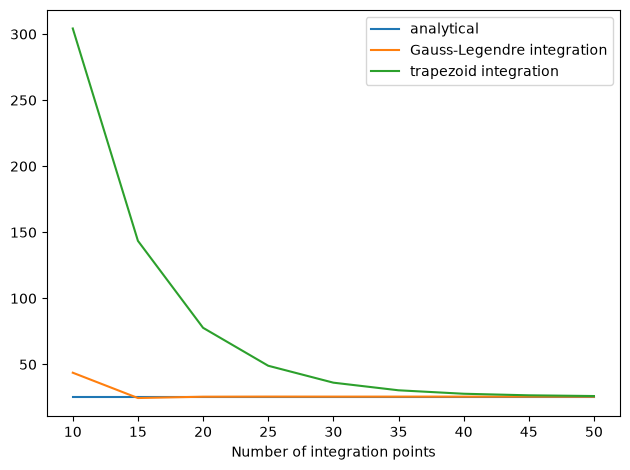

In [73]:
### Question 1: Plotting integrands
S = 1000
s = log(S)
r = 0.02
delta = 0.01
sigma = 0.30
tau = 1 / 4
K = 1100
alpha = 0.75
bsm_params = {"S": S, "r": r, "delta": delta, "sigma": sigma}

uv = np.arange(0, 100, 0.1)  # points at which integrand is evaluated

psi = charFuncBSM(uv - (1+alpha)*1j, tau, bsm_params)
chi = exp(-r*tau) * psi / (alpha**2 + alpha - uv**2 + 1j*(1+2*alpha)*uv)
integrand = real(exp(-1j * uv * log(K)) * chi)  # integrand

plt.plot(uv, integrand)
plt.xlabel('u')
print("Q1: Plot the integrand")
save_and_show()


### Question 2: Comparison of integration schemes with analytical price
def callPrice(uv, wgtv):
    psi = charFuncBSM(uv - (1 + alpha) * 1j, tau, bsm_params)
    chi = exp(-r * tau) * psi / (alpha ** 2 + alpha - uv ** 2 + 1j * (1 + 2 * alpha) * uv)
    integrand = real(exp(-1j * uv * log(K)) * chi)  # integrand
    integral = sum(wgtv * integrand)  # computing integral by numerical integration
    price_modified = 1/pi*integral  # modified call price
    price = exp(-alpha*log(K))*price_modified  # call price
    return price

nPoints = 25  # number of integration points
upperBound = 30  # truncation of integral

# Price via the Gauss-Legendre integration scheme
uv_gl, wgtv_gl = GL_integration(upperBound, nPoints)
C_GL = callPrice(uv_gl, wgtv_gl)

# Price via trapezoid scheme
uv_tr, wgtv_tr = trap_integration(0, upperBound, nPoints)
C_Trap = callPrice(uv_tr, wgtv_tr)

# True price
C_true = BSM(S, K, delta, r, sigma, tau, "call")

res = np.array([C_true, C_GL, C_Trap])
print("Q2: Option prices",res)
print("")

### Question 3: Convergence to true price
nPointsv = np.linspace(10, 50, 9, dtype='int')
upperBound = 30  # truncation of integral
Cv = np.zeros((len(nPointsv), 3))  # preallocating
Cv[:, 0] = C_true
for i in range(len(nPointsv)):
    nPoints = nPointsv[i]
    uv_gl, wgtv_gl = GL_integration(upperBound, nPoints)
    Cv[i, 1] = callPrice(uv_gl, wgtv_gl)
    uv_tr, wgtv_tr = trap_integration(0, upperBound, nPoints)
    Cv[i, 2] = callPrice(uv_tr, wgtv_tr)

print("Q3: Convergence to true price:",Cv)
print("")

plt.plot(nPointsv, Cv)
plt.gca().legend(('analytical', 'Gauss-Legendre integration', 'trapezoid integration'))
plt.xlabel('Number of integration points')
save_and_show()

# Lecture 5
### Showing how the efficacy of antithetic variates and control variates (with arithmetic average) depends on moneyness

Define the arithmetic average as $$A_d \;=\; \frac{1}{n}\sum_{i=1}^n S_{t_i},
\qquad t_i = i \Delta t$$
Then its expectation is
$$
\mathbb{E}[A_d]
= \frac{S_0}{n}\cdot
\frac{e^{(r-q)\Delta t}\big(1 - e^{(r-q)n\Delta t}\big)}{1 - e^{(r-q)\Delta t}}
$$

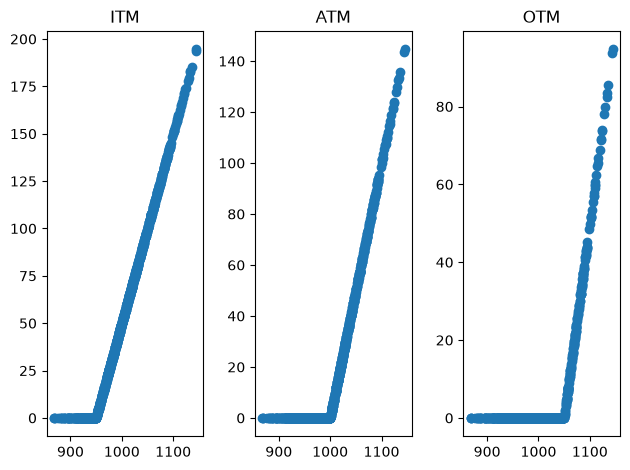

Correlations:
 [0.9780 0.8766 0.6600]
Width of confidence intervals:
 [[5.6301 3.8463 1.7663]
 [1.7877 2.8666 1.7441]
 [1.1749 1.8506 1.3270]]


In [74]:
S = 1000
s = log(S)
r = 0.02
delta = 0.01
sigma = 0.30

T = 1/12 #option maturity
dt = 1/252 #time step
n = int(T/dt) #number of steps per path

nSim = 1000
CI_width = np.zeros((3,3))
correlation = np.zeros(3)
Ks = {"ITM": 950, "ATM": 1000, "OTM": 1050}
EX = 1/n*S*(exp((r-delta)*dt)-exp((r-delta)*dt*(n+1)))/(1-exp((r-delta)*dt))  # E[arithmetic average]

for col, (label, K) in enumerate(Ks.items()):

    ## Regular MC
    np.random.seed(1) #resetting random number generator
    Y = np.zeros(nSim)
    for j in range(nSim):
        path = simulate_gbm_path(S, r, delta, sigma, dt, n)
        Y[j] = exp(-r*T)*max([0, mean(path) - K])
    _, ci = plain_mc_estimate(Y)
    CI_width[0, col] = ci[1] - ci[0]

    ## Antithetic variates
    np.random.seed(1) #resetting random number generator
    nSim_AV = int(nSim/2)
    Y_av = np.zeros(nSim_AV)
    Ytilde = np.zeros(nSim_AV)
    for j in range(nSim_AV):
        eps = np.random.normal(size=n)  # original eps
        path = simulate_gbm_path(S, r, delta, sigma, dt, n, eps=eps)
        Y_av[j] = exp(-r * T) * max([0, mean(path) - K])
        path = simulate_gbm_path(S, r, delta, sigma, dt, n, eps=-eps)  # antithetic path
        Ytilde[j] = exp(-r * T) * max([0, mean(path) - K])
    _, ci = antithetic_estimate(Y_av, Ytilde)
    CI_width[1, col] = ci[1] - ci[0]

    ## Control variates with arithmetic average
    np.random.seed(1) #resetting random number generator
    Y = np.zeros(nSim)
    X = np.zeros(nSim)
    for j in range(nSim):
        path = simulate_gbm_path(S, r, delta, sigma, dt, n)
        Y[j] = exp(-r*T)*max([0, mean(path) - K])
        X[j] = mean(path)
    _, ci, corr = control_variate_estimate(Y, X, EX)
    correlation[col] = corr
    CI_width[2, col] = ci[1] - ci[0]

    plt.subplot(1, 3, col + 1)
    plt.scatter(X, Y)
    plt.title(label)

save_and_show()

print('Correlations:\n',correlation)
print('Width of confidence intervals:\n',CI_width)

# Assignment 5

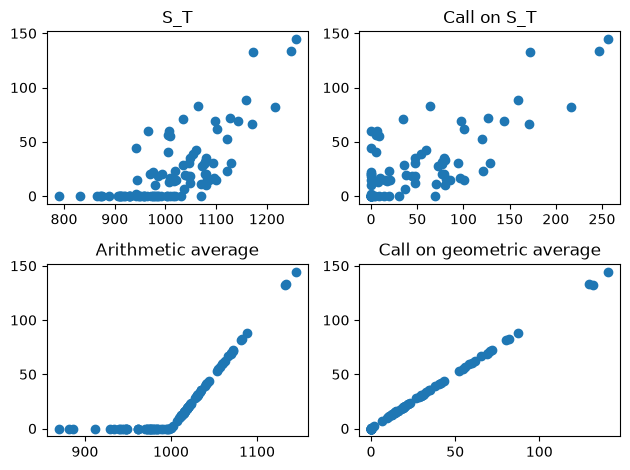

Estimate:
 [22.6526 17.7420 19.6568 20.3823 19.0408 20.8923]
Width of confidence intervals:
 [12.1375  8.3023  8.2632  7.5649  6.1299  0.1971]
Correlations:
 [0.7325 0.7820 0.8631 0.9999]


In [75]:
S = 1000
s = log(S)
r = 0.02
delta = 0.01
sigma = 0.30

T = 1/12 #option maturity
dt = 1/252 #time step
n = int(T/dt) #number of steps per path

K = 1000
nSim = 100
estimate = np.zeros(6)
CI = np.zeros((6,2))
correlation = np.zeros(4)

## Regular MC
np.random.seed(1) #resetting random number generator
Y = np.zeros(nSim)
for j in range(nSim):
    path = simulate_gbm_path(S, r, delta, sigma, dt, n)
    Y[j] = exp(-r*T)*max([0, mean(path) - K])
estimate[0], CI[0,:] = plain_mc_estimate(Y)

## Antithetic variates
np.random.seed(1) #resetting random number generator
nSim_AV = int(nSim/2)
Y_av = np.zeros(nSim_AV)
Ytilde = np.zeros(nSim_AV)
for j in range(nSim_AV):
    eps = np.random.normal(size=n)  # original eps
    path = simulate_gbm_path(S, r, delta, sigma, dt, n, eps=eps)
    Y_av[j] = exp(-r * T) * max([0, mean(path) - K])
    path = simulate_gbm_path(S, r, delta, sigma, dt, n, eps=-eps)  # antithetic path
    Ytilde[j] = exp(-r * T) * max([0, mean(path) - K])
estimate[1], CI[1,:] = antithetic_estimate(Y_av, Ytilde)

## Control variates with terminal value
np.random.seed(1) #resetting random number generator
Y = np.zeros(nSim)
X = np.zeros(nSim)
EX = S*exp((r-delta)*T)
for j in range(nSim):
    path = simulate_gbm_path(S, r, delta, sigma, dt, n)
    Y[j] = exp(-r*T)*max([0, mean(path) - K])
    X[j] = path[-1]
estimate[2], CI[2,:], correlation[0] = control_variate_estimate(Y, X, EX)
plt.subplot(221)
plt.scatter(X,Y)
plt.title('S_T')

## Control variates with standard call price
np.random.seed(1) #resetting random number generator
Y = np.zeros(nSim)
X = np.zeros(nSim)
EX = exp(r*T)*BSM(S, K, delta, r, sigma, T, "call")
for j in range(nSim):
    path = simulate_gbm_path(S, r, delta, sigma, dt, n)
    Y[j] = exp(-r*T)*max([0, mean(path) - K])
    S_T = path[-1]
    X[j] = max([0,S_T-K])
estimate[3], CI[3,:], correlation[1] = control_variate_estimate(Y, X, EX)
plt.subplot(222)
plt.scatter(X,Y)
plt.title('Call on S_T')

## Control variates with arithmetic average
np.random.seed(1) #resetting random number generator
Y = np.zeros(nSim)
X = np.zeros(nSim)
EX = 1/n*S*(exp((r-delta)*dt)-exp((r-delta)*dt*(n+1)))/(1-exp((r-delta)*dt))
for j in range(nSim):
    path = simulate_gbm_path(S, r, delta, sigma, dt, n)
    Y[j] = exp(-r*T)*max([0, mean(path) - K])
    X[j] = mean(path)
estimate[4], CI[4,:], correlation[2] = control_variate_estimate(Y, X, EX)
plt.subplot(223)
plt.scatter(X,Y)
plt.title('Arithmetic average')

## Control variates with call on geometric average
np.random.seed(1) #resetting random number generator
Y = np.zeros(nSim)
X = np.zeros(nSim)
iv = np.arange(1, n+1) #i running from 1 to n
T_bar = 1/n*sum(iv*dt)
sigma_bar = sqrt(sigma**2/(n**2*T_bar)*sum( (2*iv-1)*(n+1-iv)*dt ))
delta_bar = delta+1/2*sigma**2-1/2*sigma_bar**2
EX = exp(r*T_bar)*BSM(S, K, delta_bar, r, sigma_bar, T_bar, "call")
for j in range(nSim):
    path = simulate_gbm_path(S, r, delta, sigma, dt, n)
    Y[j] = exp(-r*T)*max([0, mean(path) - K])
    X[j] = max([0, np.prod(path)**(1/n) - K])
estimate[5], CI[5,:], correlation[3] = control_variate_estimate(Y, X, EX)
plt.subplot(224)
plt.scatter(X,Y)
plt.title('Call on geometric average')
save_and_show()

print('Estimate:\n',estimate)
print('Width of confidence intervals:\n',CI[:,1]-CI[:,0])
print('Correlations:\n',correlation)